# IPL Player Segmentation using Clustering


Scenario: We are the analytics team for an IPL franchise. Our goal is to segment players based on their batting and bowling performance metrics so that the team management can:



## Step 0: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
print("All libraries imported successfully!")


All libraries imported successfully!


## Step 1: Synthetic Dataset Creation

We simulate 200 IPL players across four natural archetypes:
1. Aggressive Batsmen – high SR, high runs, poor bowling
2. Anchor Batsmen – high avg, moderate SR, poor bowling
3. Pace Bowlers – good economy & bowling avg, low batting
4. All-Rounders – decent at both




In [118]:
def generate_ipl_dataset(n=200, seed=42):
    rng = np.random.default_rng(seed)
    roles        = ['Batsman', 'Batsman', 'Bowler', 'All-rounder', 'WK-Batsman']
    role_weights = [0.30,       0.20,      0.28,      0.15,           0.07]
    player_roles = rng.choice(roles, size=n, p=role_weights)
    data = []
    for role in player_roles:
        if role == 'Batsman':
            # Aggressive profile
            batting_avg  = rng.normal(38, 8)
            strike_rate  = rng.normal(148, 18)
            runs_scored  = rng.normal(520, 110)
            wickets      = rng.integers(0, 4)
            economy_rate = rng.normal(9.5, 1.2)
            bowling_avg  = rng.normal(55, 12)
            exp          = rng.integers(3, 14)
            
        elif role == 'WK-Batsman':
            batting_avg  = rng.normal(32, 7)
            strike_rate  = rng.normal(135, 15)
            runs_scored  = rng.normal(410, 90)
            wickets      = 0
            economy_rate = 10.0
            bowling_avg  = 60.0
            exp          = rng.integers(2, 12)
            
        elif role == 'Bowler':
            batting_avg  = rng.normal(12, 5)
            strike_rate  = rng.normal(95, 20)
            runs_scored  = rng.integers(10, 120)
            wickets      = rng.normal(18, 6)
            economy_rate = rng.normal(7.8, 1.0)
            bowling_avg  = rng.normal(22, 5)
            exp          = rng.integers(2, 15)
            
        else:  # All-rounder
            batting_avg  = rng.normal(28, 7)
            strike_rate  = rng.normal(130, 15)
            runs_scored  = rng.normal(320, 100)
            wickets      = rng.normal(12, 5)
            economy_rate = rng.normal(8.4, 0.9)
            bowling_avg  = rng.normal(28, 6)
            exp          = rng.integers(3, 13)
        
        data.append({
            'batting_avg':   max(0, round(batting_avg, 2)),
            'strike_rate':   max(0, round(strike_rate, 2)),
            'runs_scored':   max(0, int(runs_scored)),
            'wickets':       max(0, int(wickets)),
            'economy_rate':  max(0, round(economy_rate, 2)),
            'bowling_avg':   max(0, round(bowling_avg, 2)),
            'player_role':   role,
            'experience_years': int(exp),
        })
    
    df = pd.DataFrame(data)
    
    # Add outliers
    outlier_rows = pd.DataFrame([
        {'batting_avg': 89.5, 'strike_rate': 210.3, 'runs_scored': 973,
         'wickets': 0, 'economy_rate': 12.0, 'bowling_avg': 80.0,
         'player_role': 'Batsman', 'experience_years': 10},
        {'batting_avg': 4.0,  'strike_rate': 60.0,  'runs_scored': 22,
         'wickets': 34, 'economy_rate': 5.8, 'bowling_avg': 11.2,
         'player_role': 'Bowler', 'experience_years': 12},
        {'batting_avg': 72.0, 'strike_rate': 185.0, 'runs_scored': 840,
         'wickets': 22, 'economy_rate': 7.1, 'bowling_avg': 16.5,
         'player_role': 'All-rounder', 'experience_years': 9},
        {'batting_avg': 2.0,  'strike_rate': 45.0,  'runs_scored': 8,
         'wickets': 38, 'economy_rate': 6.1, 'bowling_avg': 10.5,
         'player_role': 'Bowler', 'experience_years': 14},
        {'batting_avg': 95.0, 'strike_rate': 220.0, 'runs_scored': 1050,
         'wickets': 1, 'economy_rate': 11.5, 'bowling_avg': 75.0,
         'player_role': 'Batsman', 'experience_years': 7},
    ])
    df = pd.concat([df, outlier_rows], ignore_index=True)
    
    #Introduce missing values (~15%)
    cols_with_missing = ['batting_avg', 'economy_rate', 'bowling_avg',
                         'wickets', 'strike_rate']
    for col in cols_with_missing:
        missing_idx = rng.choice(df.index, size=int(0.15 * len(df)), replace=False)
        df.loc[missing_idx, col] = np.nan
    
    # Add player names
    ipl_names = [
        "Rohit", "Virat", "Dhoni", "Bumrah", "Hardik", "KL Rahul",
        "Shikhar", "Rishabh", "Jadeja", "Chahal", "Suryakumar",
        "Iyer", "Siraj", "Ashwin", "Maxwell", "Warner", "Russell",
        "Narine", "Pollard", "Bravo", "Buttler", "Stokes", "Archer",
        "Rashid", "Starc"
    ]
    names = [f"{rng.choice(ipl_names)}_{i}" for i in range(len(df))]
    df.insert(0, 'player_name', names)
    
    return df

df_raw = generate_ipl_dataset()
print(f"Dataset created: {df_raw.shape[0]} players × {df_raw.shape[1]} features")
print(f"\nFirst 5 rows:")
df_raw.head()


Dataset created: 205 players × 9 features

First 5 rows:


,player_name,batting_avg,strike_rate,runs_scored,wickets,economy_rate,bowling_avg,player_role,experience_years
0,Dhoni_0,15.22,87.11,64,17.0,8.14,29.04,Bowler,8
1,Narine_1,38.72,159.59,294,1.0,8.49,40.37,Batsman,8
2,Rohit_2,21.85,NaN,411,5.0,8.43,25.09,All-rounder,12
3,Maxwell_3,17.01,105.76,43,26.0,7.65,NaN,Bowler,8
4,Iyer_4,39.94,151.18,400,0.0,9.61,57.74,Batsman,3


In [92]:
print("Dataset Info:")
print(df_raw.dtypes)
print(f"\nMissing values per column:")
print(df_raw.isnull().sum())
print(f"\nTotal missing: {df_raw.isnull().sum().sum()} / {df_raw.shape[0]*df_raw.shape[1]} = "
      f"{df_raw.isnull().sum().sum()/(df_raw.shape[0]*df_raw.shape[1])*100:.1f}%")


Dataset Info:
player_name             str
batting_avg         float64
strike_rate         float64
runs_scored           int64
wickets             float64
economy_rate        float64
bowling_avg         float64
player_role             str
experience_years      int64
dtype: object

Missing values per column:
player_name          0
batting_avg         30
strike_rate         30
runs_scored          0
wickets             30
economy_rate        30
bowling_avg         30
player_role          0
experience_years     0
dtype: int64

Total missing: 150 / 1845 = 8.1%


## Step 2: Exploratory Data Analysis (EDA)




In [93]:
print("Descriptive Statistics:")
df_raw.describe(include='all').round(2)


Descriptive Statistics:


,player_name,batting_avg,strike_rate,runs_scored,wickets,economy_rate,bowling_avg,player_role,experience_years
count,205,175.00,175.00,205.00,175.00,175.00,175.00,205,205.00
unique,205,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN
top,Dhoni_0,NaN,NaN,NaN,NaN,NaN,NaN,Batsman,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,106,NaN
mean,NaN,29.52,128.98,353.98,6.90,8.86,42.23,NaN,7.96
std,NaN,15.07,31.07,226.22,8.02,1.37,19.39,NaN,3.37
min,NaN,2.00,43.67,8.00,0.00,5.15,10.50,NaN,2.00
25%,NaN,17.07,108.39,99.00,1.00,7.98,24.16,NaN,5.00
50%,NaN,29.88,133.13,400.00,3.00,8.82,42.30,NaN,8.00
75%,NaN,39.66,151.01,519.00,13.00,9.93,58.90,NaN,11.00


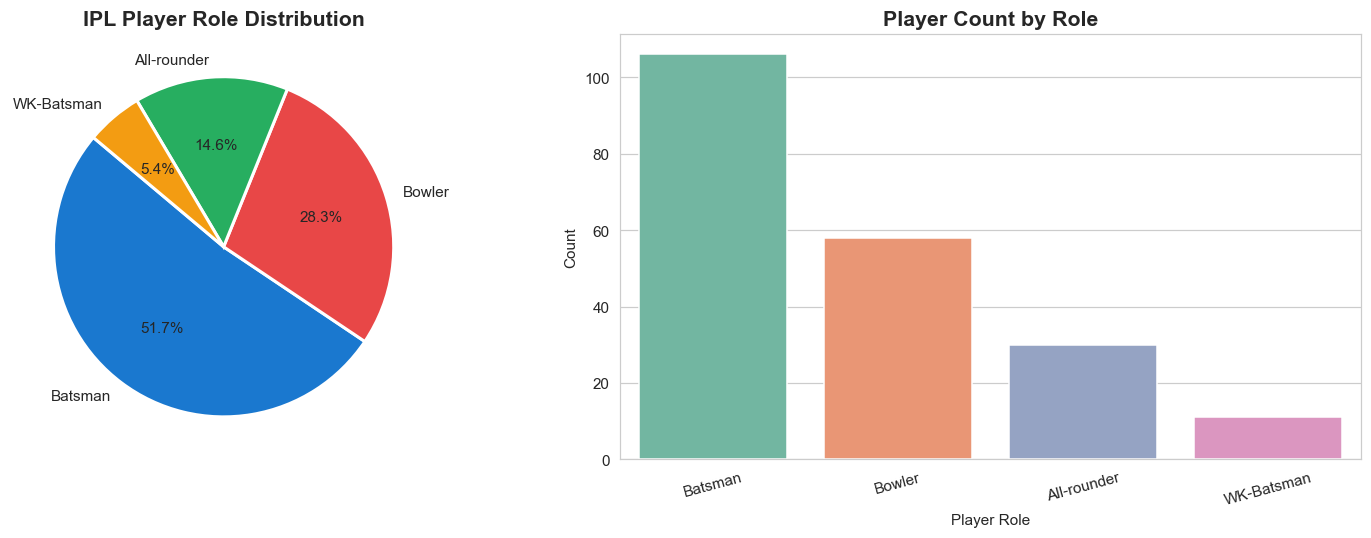

Role distribution plotted


In [94]:
#2.1 Player Role Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

role_counts = df_raw['player_role'].value_counts()
colors = ['#1a78cf', '#e84747', '#27ae60', '#f39c12', '#8e44ad']
axes[0].pie(role_counts, labels=role_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('IPL Player Role Distribution', fontsize=14, fontweight='bold')

sns.countplot(data=df_raw, x='player_role', ax=axes[1], palette='Set2',
              order=role_counts.index)
axes[1].set_title('Player Count by Role', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Player Role')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('eda_role_distribution.png', bbox_inches='tight')
plt.show()
print("Role distribution plotted")


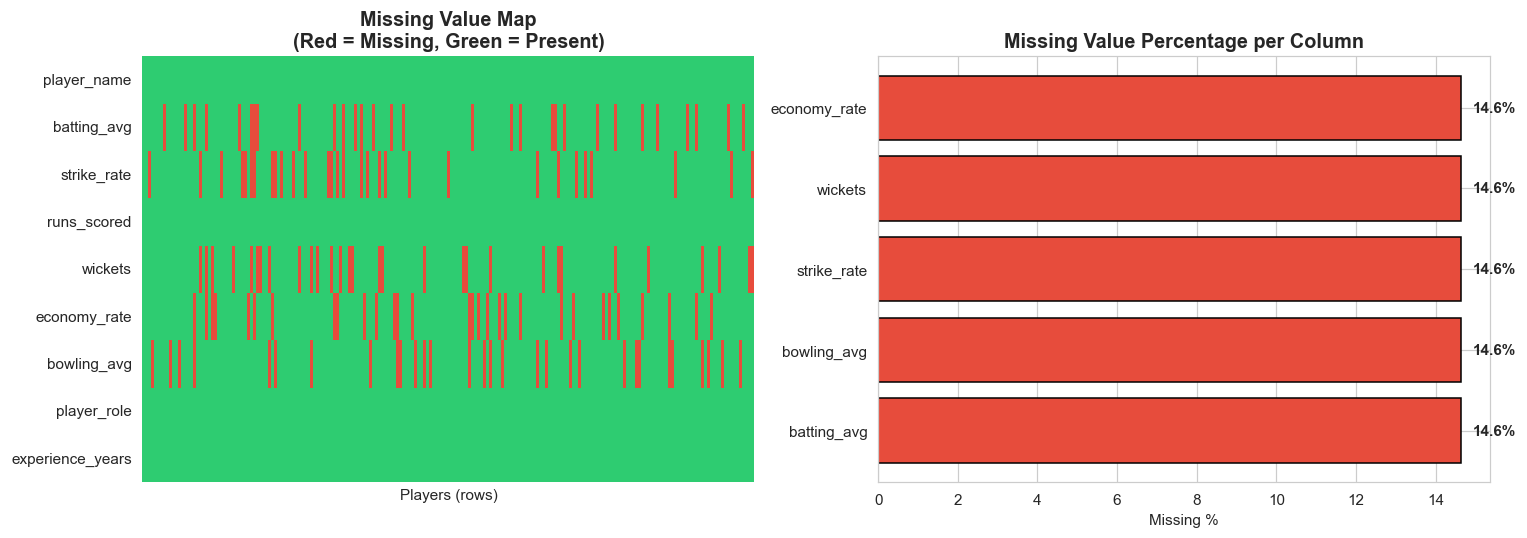

Columns with missing values: ['batting_avg', 'bowling_avg', 'strike_rate', 'wickets', 'economy_rate']


In [95]:
#2.2 Missing Value Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
missing_matrix = df_raw.isnull().astype(int)
sns.heatmap(missing_matrix.T, cmap=['#2ecc71', '#e74c3c'],
            ax=axes[0], cbar=False, yticklabels=True, xticklabels=False)
axes[0].set_title('Missing Value Map\n(Red = Missing, Green = Present)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Players (rows)')

# Bar chart of missing %
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
axes[1].barh(missing_pct.index, missing_pct.values, color='#e74c3c', edgecolor='black')
axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Value Percentage per Column', fontsize=13, fontweight='bold')
for i, v in enumerate(missing_pct.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_missing_values.png', bbox_inches='tight')
plt.show()
print(f"Columns with missing values: {list(missing_pct.index)}")


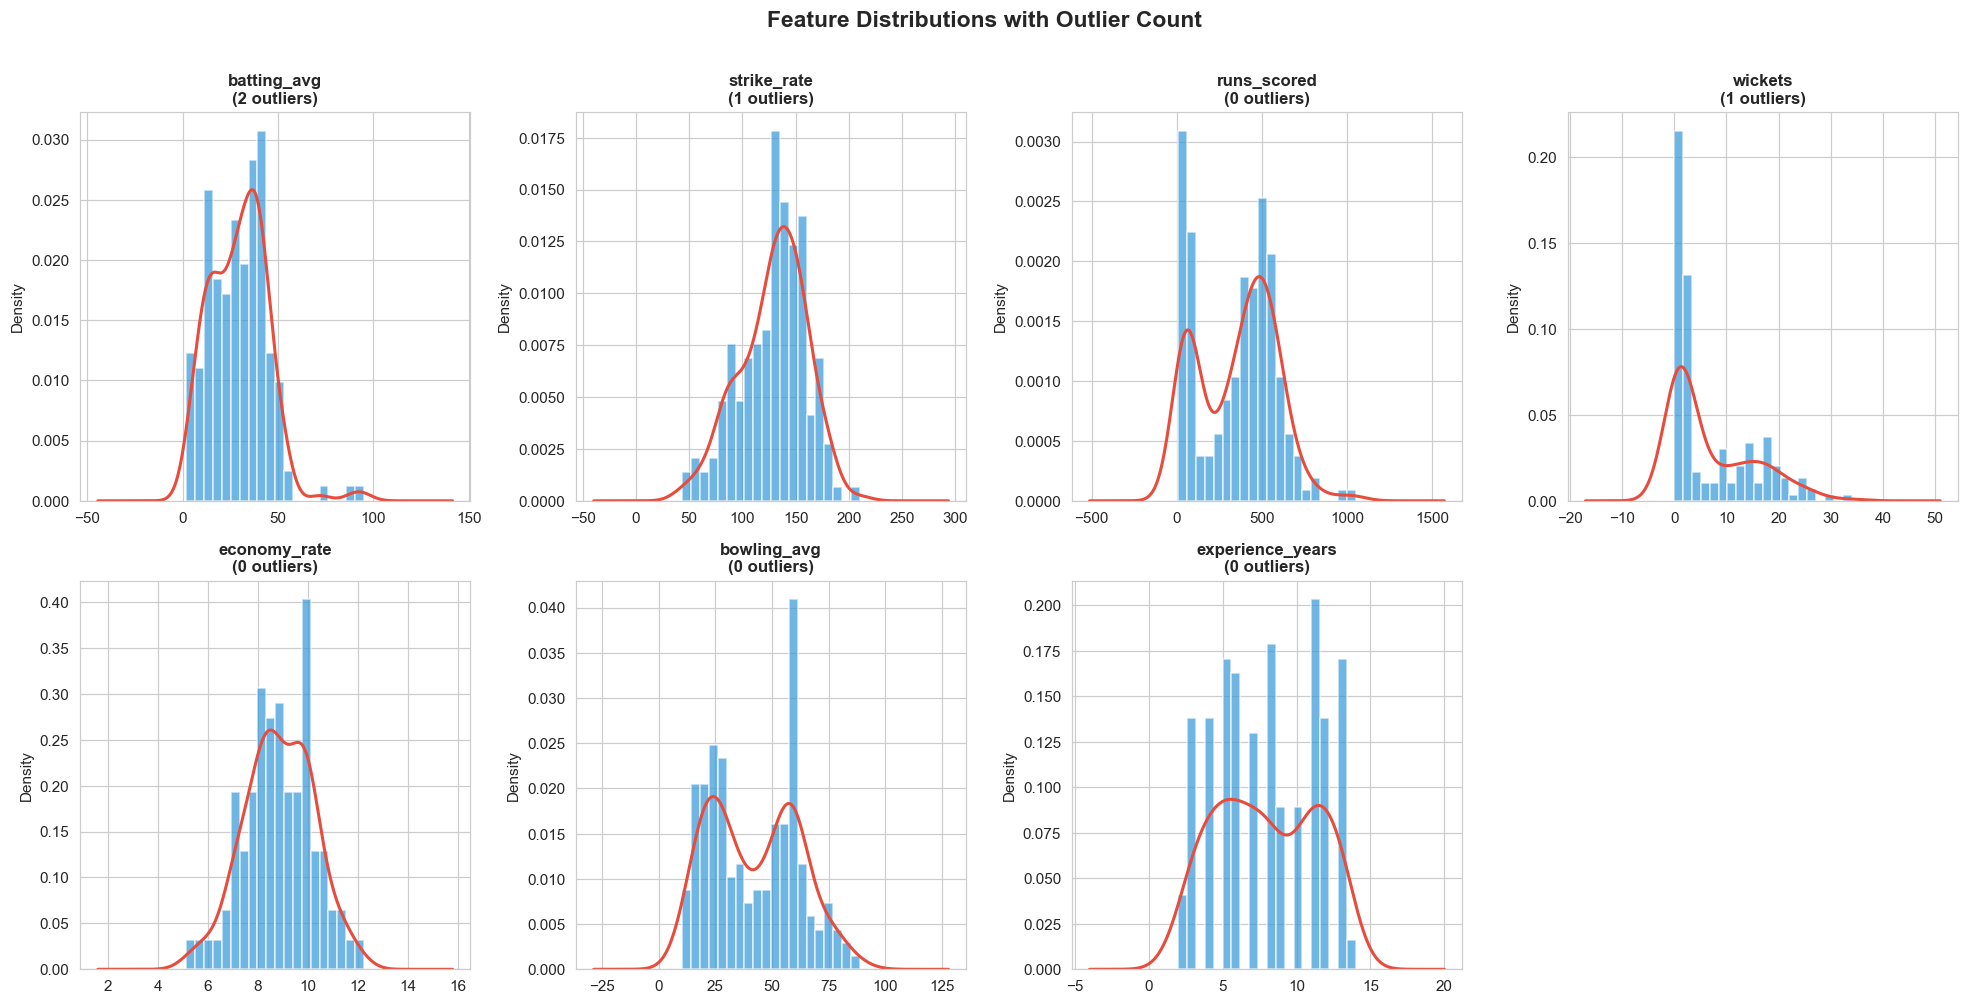

In [96]:
#2.3 Distributions & Outliers via Boxplots 
num_cols = ['batting_avg', 'strike_rate', 'runs_scored',
            'wickets', 'economy_rate', 'bowling_avg', 'experience_years']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_col = df_raw[col].dropna()
    
    
    axes[i].hist(data_col, bins=20, color='#3498db', alpha=0.7, edgecolor='white', density=True)
    data_col.plot.kde(ax=axes[i], color='#e74c3c', linewidth=2)
    
    
    Q1, Q3 = data_col.quantile(0.25), data_col.quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (data_col < Q1 - 1.5*IQR) | (data_col > Q3 + 1.5*IQR)
    n_out = outlier_mask.sum()
    
    axes[i].set_title(f'{col}\n({n_out} outliers)', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
fig.suptitle('Feature Distributions with Outlier Count', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()


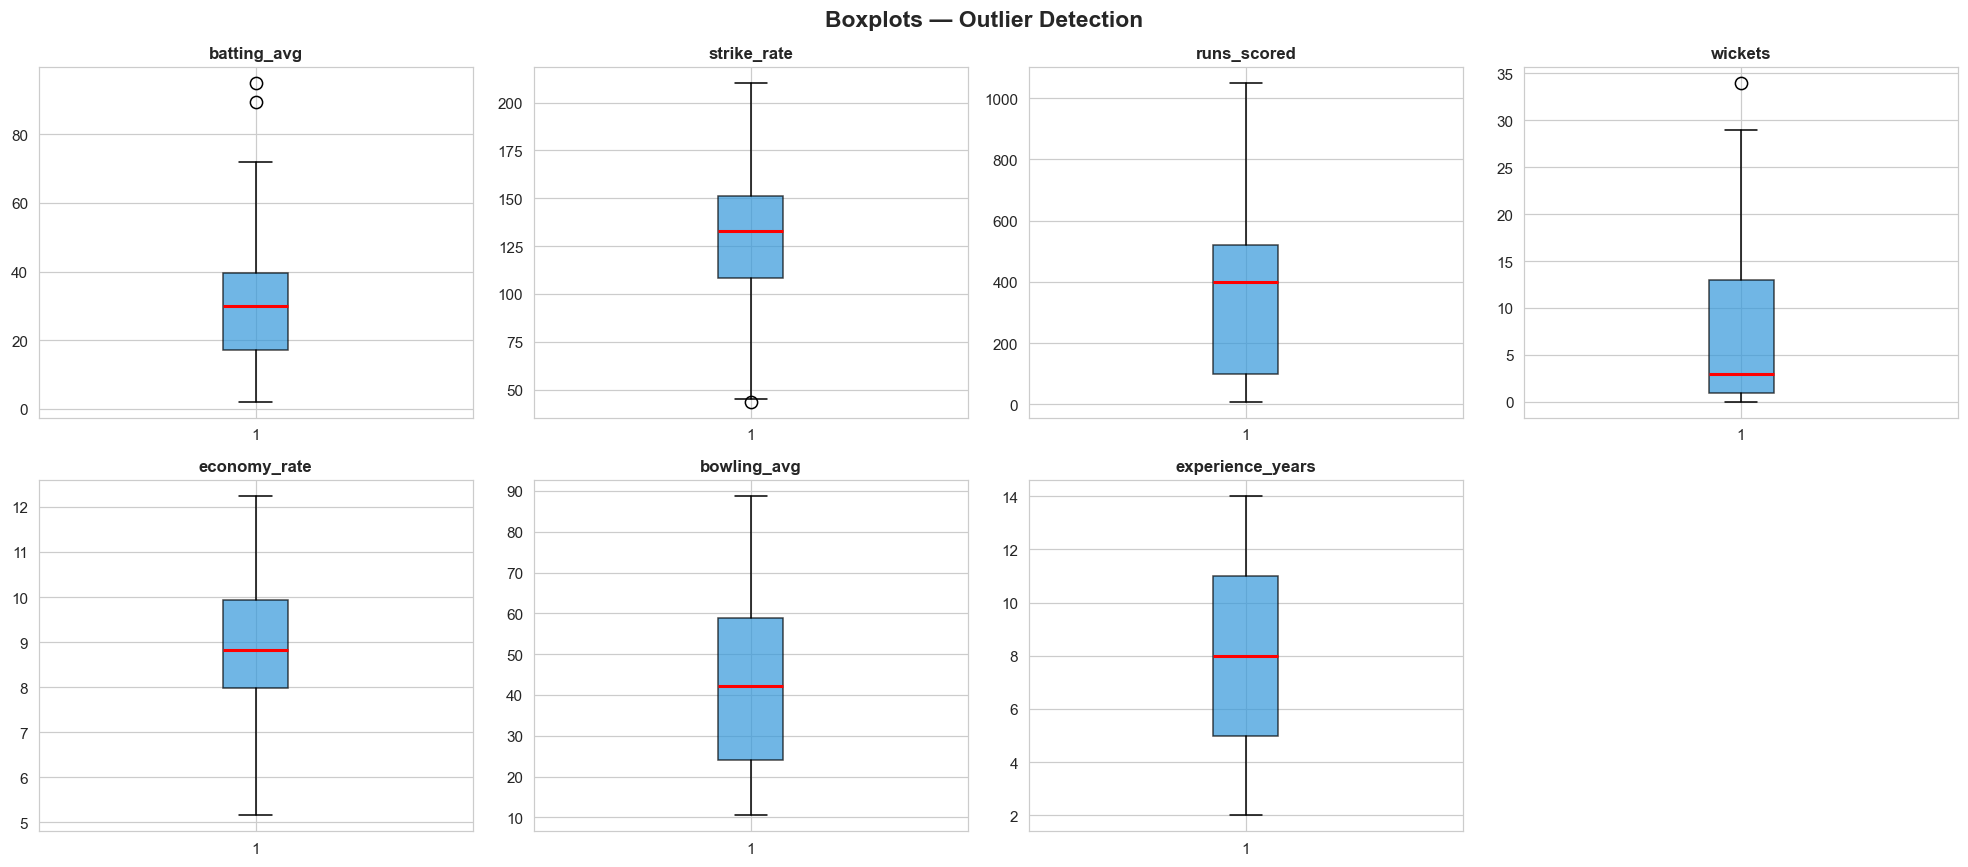

dots=potential outliers


In [97]:
#2.4 Boxplots to spot outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df_raw[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='white', markersize=8))
    axes[i].set_title(col, fontsize=11, fontweight='bold')

axes[-1].set_visible(False)
fig.suptitle('Boxplots — Outlier Detection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplots.png', bbox_inches='tight')
plt.show()
print("dots=potential outliers")


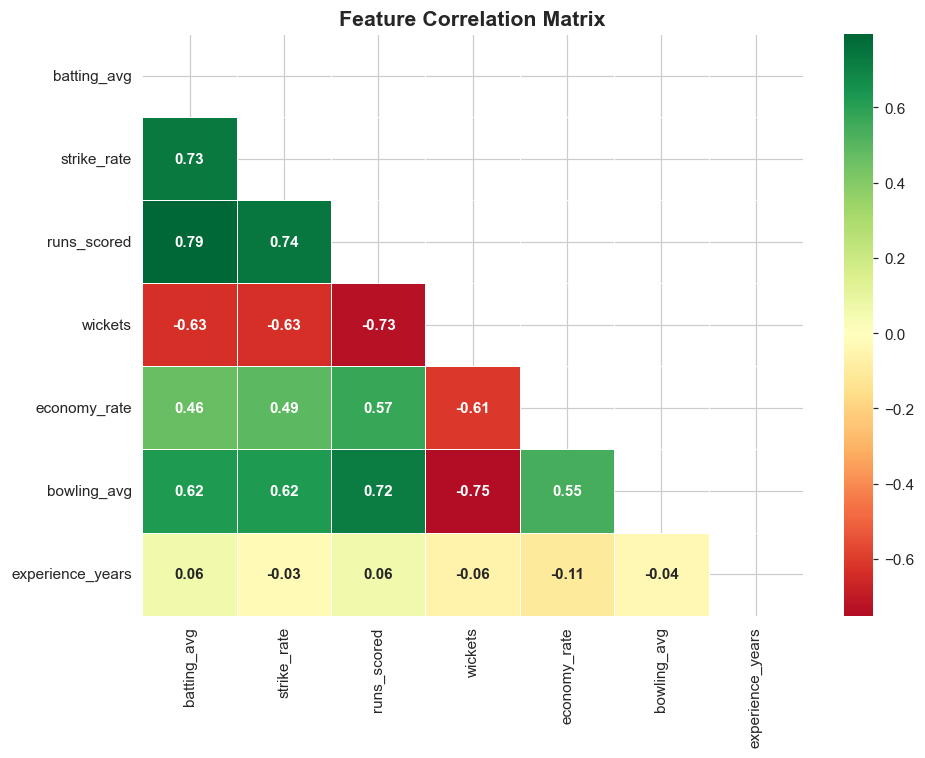

Key insight: batting_avg & runs_scored are positively correlated.


In [98]:
#2.5 Correlation Heatmap 
fig, ax = plt.subplots(figsize=(9, 7))
corr = df_raw[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 10, 'weight': 'bold'})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()
print("Key insight: batting_avg & runs_scored are positively correlated.")



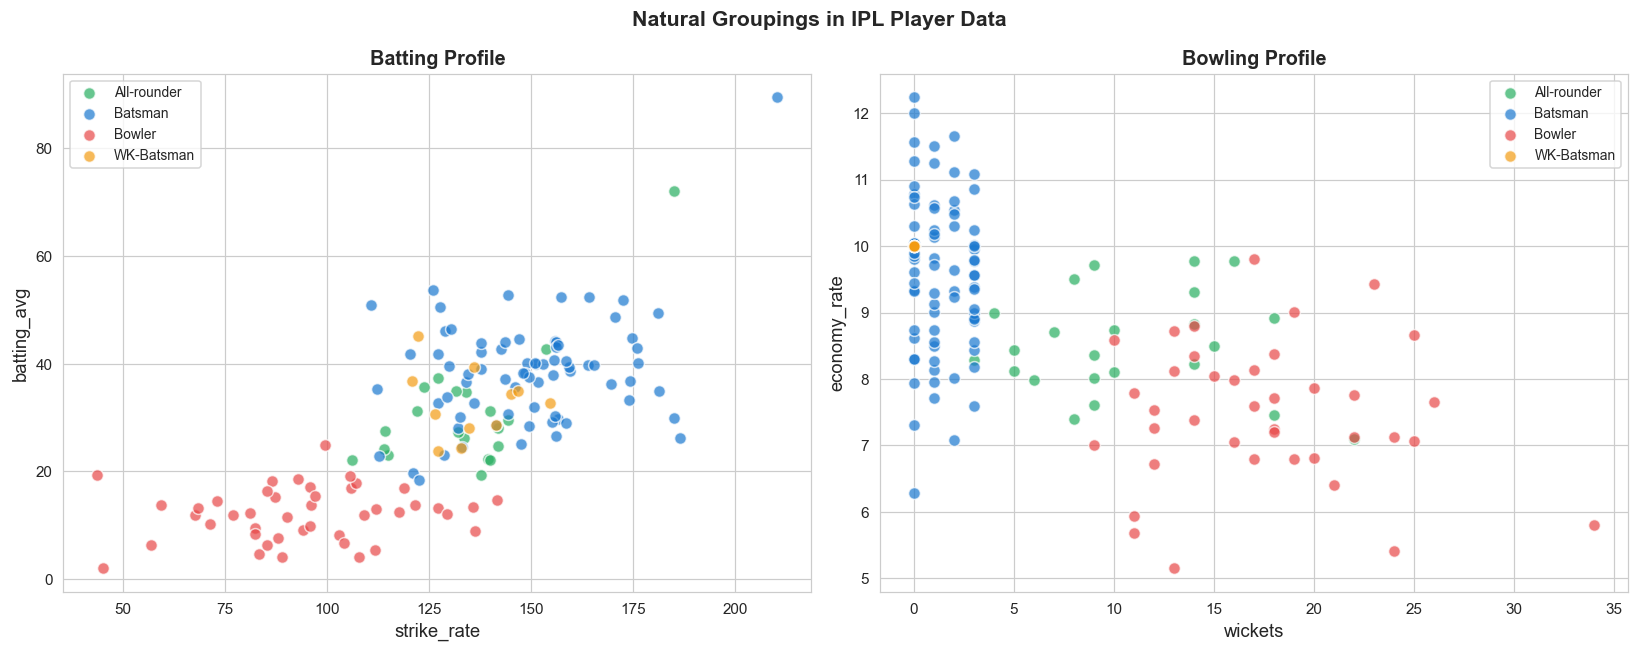

In [99]:
#2.6 Scatter: Natural groupings 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
role_palette = {'Batsman':'#1a78cf', 'Bowler':'#e84747',
                'All-rounder':'#27ae60', 'WK-Batsman':'#f39c12'}

for ax, (xcol, ycol, title) in zip(axes, [
    ('strike_rate', 'batting_avg', 'Batting Profile'),
    ('wickets',     'economy_rate', 'Bowling Profile')
]):
    for role, grp in df_raw.groupby('player_role'):
        ax.scatter(grp[xcol], grp[ycol], label=role, alpha=0.7,
                   color=role_palette.get(role, 'grey'), edgecolors='white', s=60)
    ax.set_xlabel(xcol, fontsize=12)
    ax.set_ylabel(ycol, fontsize=12)
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Natural Groupings in IPL Player Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_scatter.png', bbox_inches='tight')
plt.show()



## Step 3: Data Preprocessing






In [100]:
df = df_raw.copy()

#3.1 Encode categorical variable
le = LabelEncoder()
df['player_role_enc'] = le.fit_transform(df['player_role'])
print("Player role encoding:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"{cls:15s} → {enc}")


Player role encoding:
All-rounder     → 0
Batsman         → 1
Bowler          → 2
WK-Batsman      → 3


In [101]:
#3.2 Handle Missing Values — Median Imputation
imputer = SimpleImputer(strategy='median')
num_cols_full = ['batting_avg', 'strike_rate', 'runs_scored',
                 'wickets', 'economy_rate', 'bowling_avg', 'experience_years']

df[num_cols_full] = imputer.fit_transform(df[num_cols_full])

print(f"Missing values after imputation: {df[num_cols_full].isnull().sum().sum()}")
print("Missing values handled using median imputation")



Missing values after imputation: 0
Missing values handled using median imputation


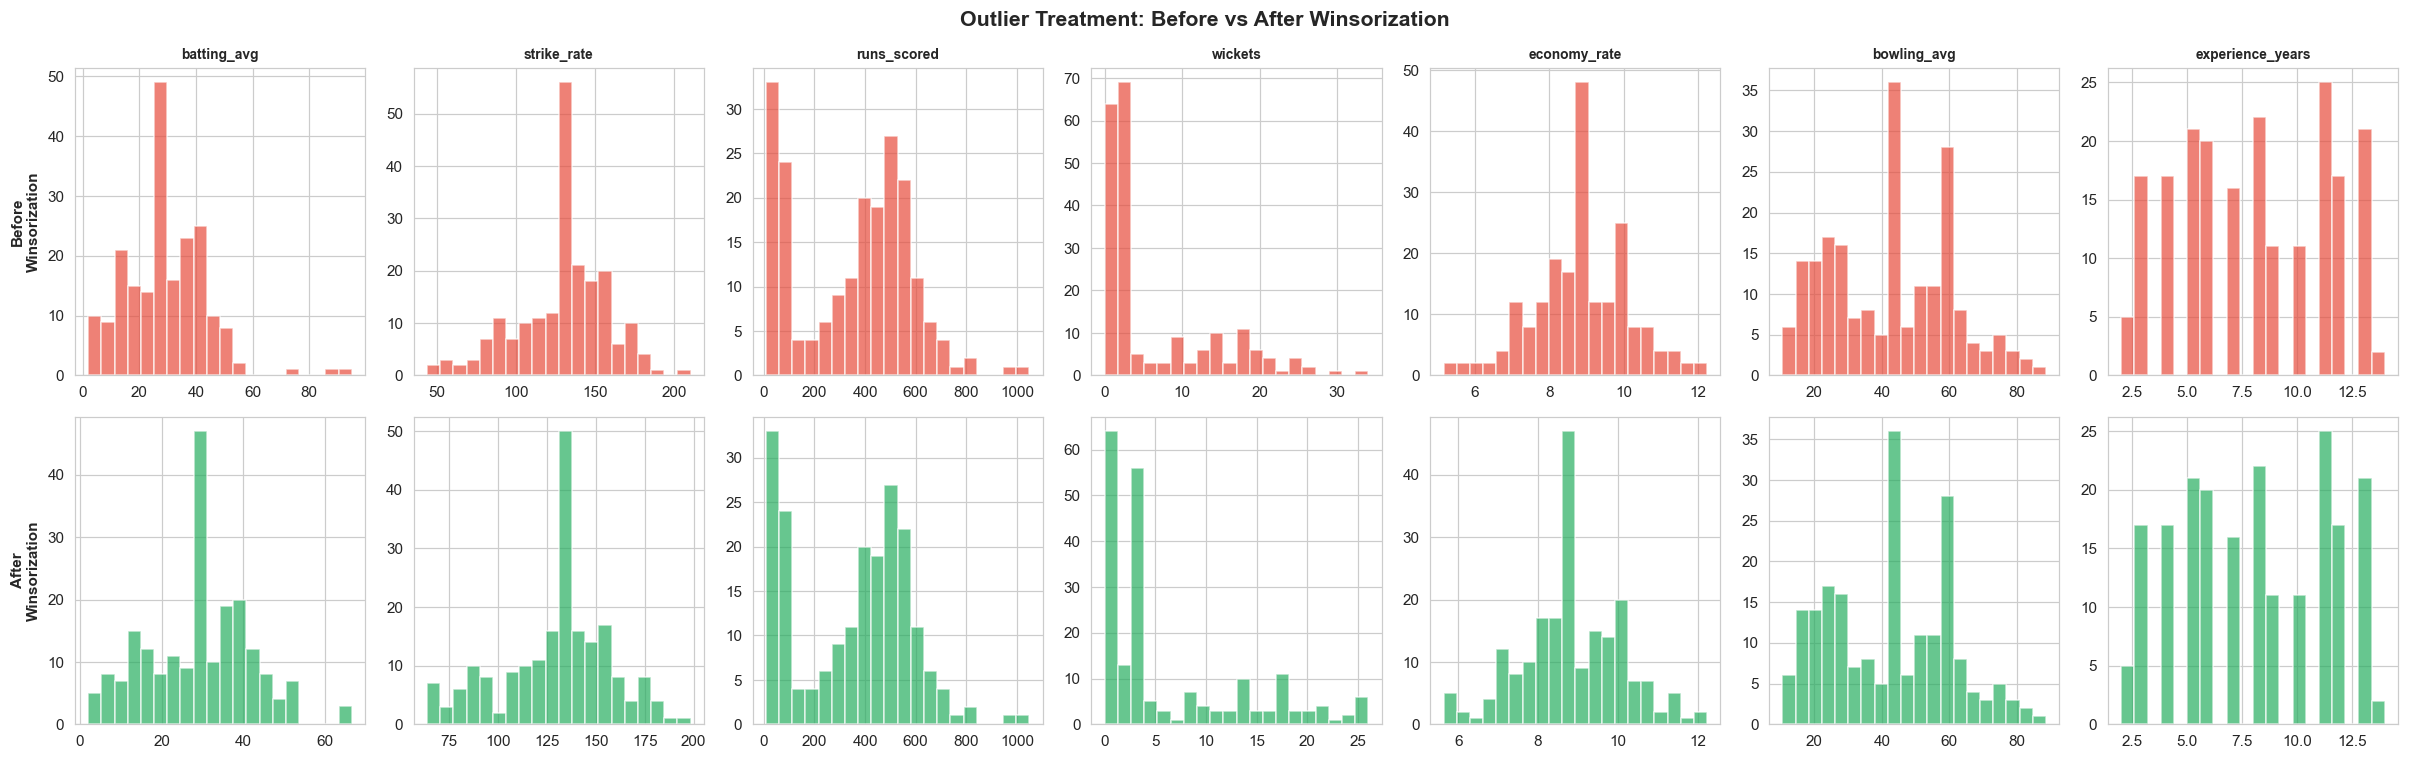

Outliers capped via Winsorization (1.5×IQR rule)


In [102]:
#3.3 Treat Outliers
def winsorize(series, factor=1.5):
    """Cap values at Q1 - factor*IQR and Q3 + factor*IQR"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
    return series.clip(lower, upper), lower, upper

fig, axes = plt.subplots(2, len(num_cols_full), figsize=(22, 7))
for i, col in enumerate(num_cols_full):
    before = df[col].copy()
    df[col], lo, hi = winsorize(df[col])
    
    # Before
    axes[0, i].hist(before, bins=20, color='#e74c3c', alpha=0.7, edgecolor='white')
    axes[0, i].set_title(col, fontsize=9, fontweight='bold')
    if i == 0: axes[0, i].set_ylabel('Before\nWinsorization', fontweight='bold')
    
    # After
    axes[1, i].hist(df[col], bins=20, color='#27ae60', alpha=0.7, edgecolor='white')
    if i == 0: axes[1, i].set_ylabel('After\nWinsorization', fontweight='bold')

plt.suptitle('Outlier Treatment: Before vs After Winsorization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing_outliers.png', bbox_inches='tight')
plt.show()
print("Outliers capped via Winsorization (1.5×IQR rule)")


In [103]:
#3.4 Feature Scaling — StandardScaler
features_for_clustering = ['batting_avg', 'strike_rate', 'runs_scored',
                            'wickets', 'economy_rate', 'bowling_avg',
                            'experience_years', 'player_role_enc']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features_for_clustering])
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)

print("Feature statistics BEFORE scaling:")
print(df[features_for_clustering].describe().loc[['mean','std']].round(2))
print("\nFeature statistics AFTER scaling (all ~ mean=0, std=1):")
print(X_scaled_df.describe().loc[['mean','std']].round(4))
print("\nAll features now on the same scale — clustering will be fair!")


Feature statistics BEFORE scaling:
      batting_avg  strike_rate  runs_scored  wickets  economy_rate  \
mean        29.30       129.79       353.98     6.27          8.86   
std         12.91        27.90       226.22     7.35          1.26   

      bowling_avg  experience_years  player_role_enc  
mean        42.24              7.96             1.24  
std         17.91              3.37             0.77  

Feature statistics AFTER scaling (all ~ mean=0, std=1):
      batting_avg  strike_rate  runs_scored  wickets  economy_rate  \
mean       0.0000      -0.0000      -0.0000  -0.0000       -0.0000   
std        1.0024       1.0024       1.0024   1.0024        1.0024   

      bowling_avg  experience_years  player_role_enc  
mean      -0.0000            0.0000          -0.0000  
std        1.0024            1.0024           1.0024  

All features now on the same scale — clustering will be fair!


## Step 4: K-Means Clustering




In [104]:
#4.1 Elbow Method + Silhouette Score 
inertias, silhouette_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f"  k={k}  |  Inertia={km.inertia_:,.1f}  |  Silhouette={silhouette_score(X_scaled, labels):.4f}")



  k=2  |  Inertia=982.6  |  Silhouette=0.3828
  k=3  |  Inertia=809.9  |  Silhouette=0.2890
  k=4  |  Inertia=722.5  |  Silhouette=0.2388
  k=5  |  Inertia=654.1  |  Silhouette=0.2581
  k=6  |  Inertia=585.9  |  Silhouette=0.2331
  k=7  |  Inertia=554.2  |  Silhouette=0.2292
  k=8  |  Inertia=518.3  |  Silhouette=0.2272
  k=9  |  Inertia=498.1  |  Silhouette=0.2140
  k=10  |  Inertia=468.5  |  Silhouette=0.2031


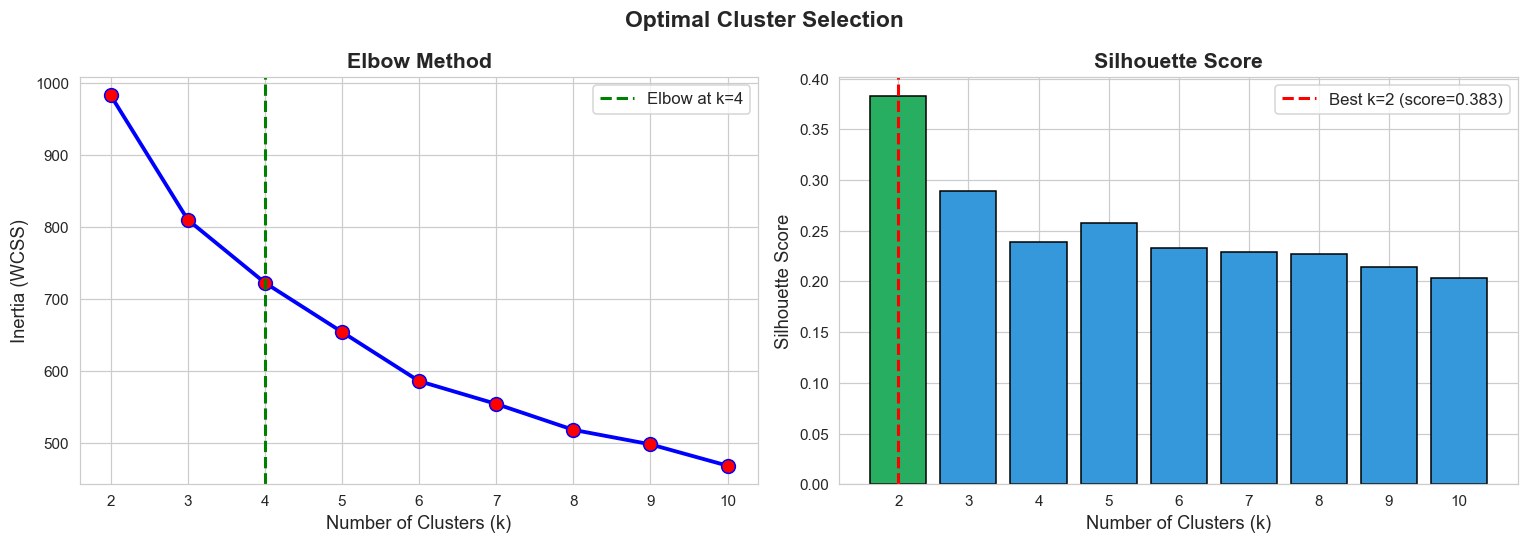


Optimal k = 2 based on Silhouette Score
   The Elbow Method also suggests k=4 aligns with our 4 player archetypes


In [105]:
#4.2 Visualise Elbow & Silhouette 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2.5, markersize=9, markerfacecolor='red')
axes[0].axvline(x=4, color='green', linestyle='--', linewidth=2, label='Elbow at k=4')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_xticks(list(K_range))

# Silhouette
bar_colors = ['#27ae60' if s == max(silhouette_scores) else '#3498db' for s in silhouette_scores]
axes[1].bar(K_range, silhouette_scores, color=bar_colors, edgecolor='black')
best_k_idx = np.argmax(silhouette_scores)
best_k = list(K_range)[best_k_idx]
axes[1].axvline(x=best_k, color='red', linestyle='--', linewidth=2,
                label=f'Best k={best_k} (score={max(silhouette_scores):.3f})')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_xticks(list(K_range))

plt.suptitle('Optimal Cluster Selection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_elbow_silhouette.png', bbox_inches='tight')
plt.show()
print(f"\nOptimal k = {best_k} based on Silhouette Score")
print("   The Elbow Method also suggests k=4 aligns with our 4 player archetypes")


In [106]:
#4.3 Fit Final K-Means Model
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=20, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['kmeans_cluster'] = kmeans_labels
print(f"K-Means fitted with k={OPTIMAL_K}")
print(f"\nCluster distribution:")
print(df['kmeans_cluster'].value_counts().sort_index())


K-Means fitted with k=4

Cluster distribution:
kmeans_cluster
0    58
1    53
2    61
3    33
Name: count, dtype: int64


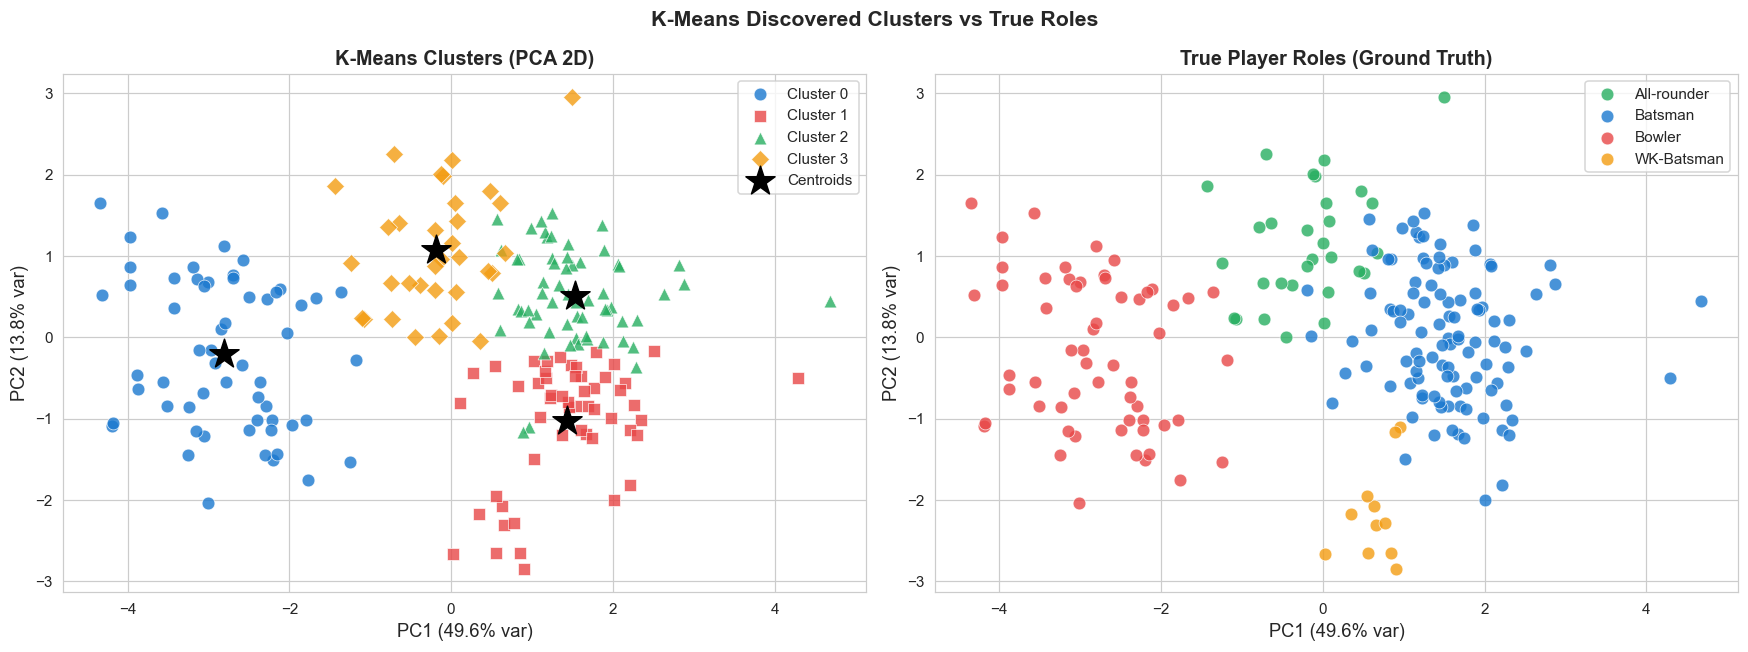

PCA explains 63.4% of variance in 2D


In [107]:
#4.4 Visualise Clusters in 2D (PCA)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cluster_colors = ['#1a78cf', '#e84747', '#27ae60', '#f39c12']
cluster_markers = ['o', 's', '^', 'D']

# K-Means clusters
for c in range(OPTIMAL_K):
    mask = kmeans_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cluster_colors[c], marker=cluster_markers[c],
                    s=70, alpha=0.8, edgecolors='white', linewidth=0.5,
                    label=f'Cluster {c}')

centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='*', s=400, zorder=5, label='Centroids')
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)', fontsize=12)
axes[0].set_title('K-Means Clusters (PCA 2D)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# True roles
role_colors = {'Batsman':'#1a78cf','Bowler':'#e84747',
               'All-rounder':'#27ae60','WK-Batsman':'#f39c12'}
for role, grp_idx in df.groupby('player_role').groups.items():
    axes[1].scatter(X_pca[grp_idx, 0], X_pca[grp_idx, 1],
                    c=role_colors.get(role, 'grey'), s=70, alpha=0.8,
                    edgecolors='white', linewidth=0.5, label=role)

axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)', fontsize=12)
axes[1].set_title('True Player Roles (Ground Truth)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('K-Means Discovered Clusters vs True Roles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clusters_pca.png', bbox_inches='tight')
plt.show()
print(f"PCA explains {sum(explained[:2])*100:.1f}% of variance in 2D")


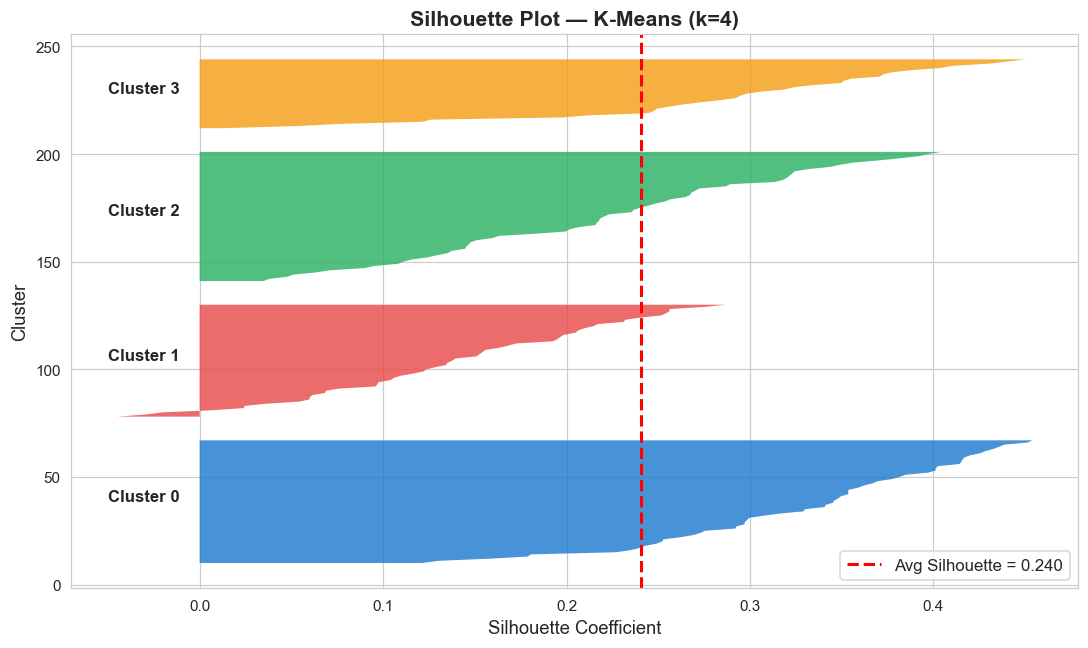

Average Silhouette Score: 0.2404


In [108]:
#4.5 Silhouette Plot
from sklearn.metrics import silhouette_samples

sil_vals = silhouette_samples(X_scaled, kmeans_labels)
sil_avg  = silhouette_score(X_scaled, kmeans_labels)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for c in range(OPTIMAL_K):
    c_sil = np.sort(sil_vals[kmeans_labels == c])
    c_size = c_sil.shape[0]
    y_upper = y_lower + c_size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=cluster_colors[c], alpha=0.8, edgecolor='none')
    ax.text(-0.05, y_lower + 0.5 * c_size, f'Cluster {c}', fontsize=11, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color='red', linestyle='--', linewidth=2,
           label=f'Avg Silhouette = {sil_avg:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Silhouette Plot — K-Means (k={OPTIMAL_K})', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('kmeans_silhouette_plot.png', bbox_inches='tight')
plt.show()
print(f"Average Silhouette Score: {sil_avg:.4f}")


## Step 5: Hierarchical Clustering




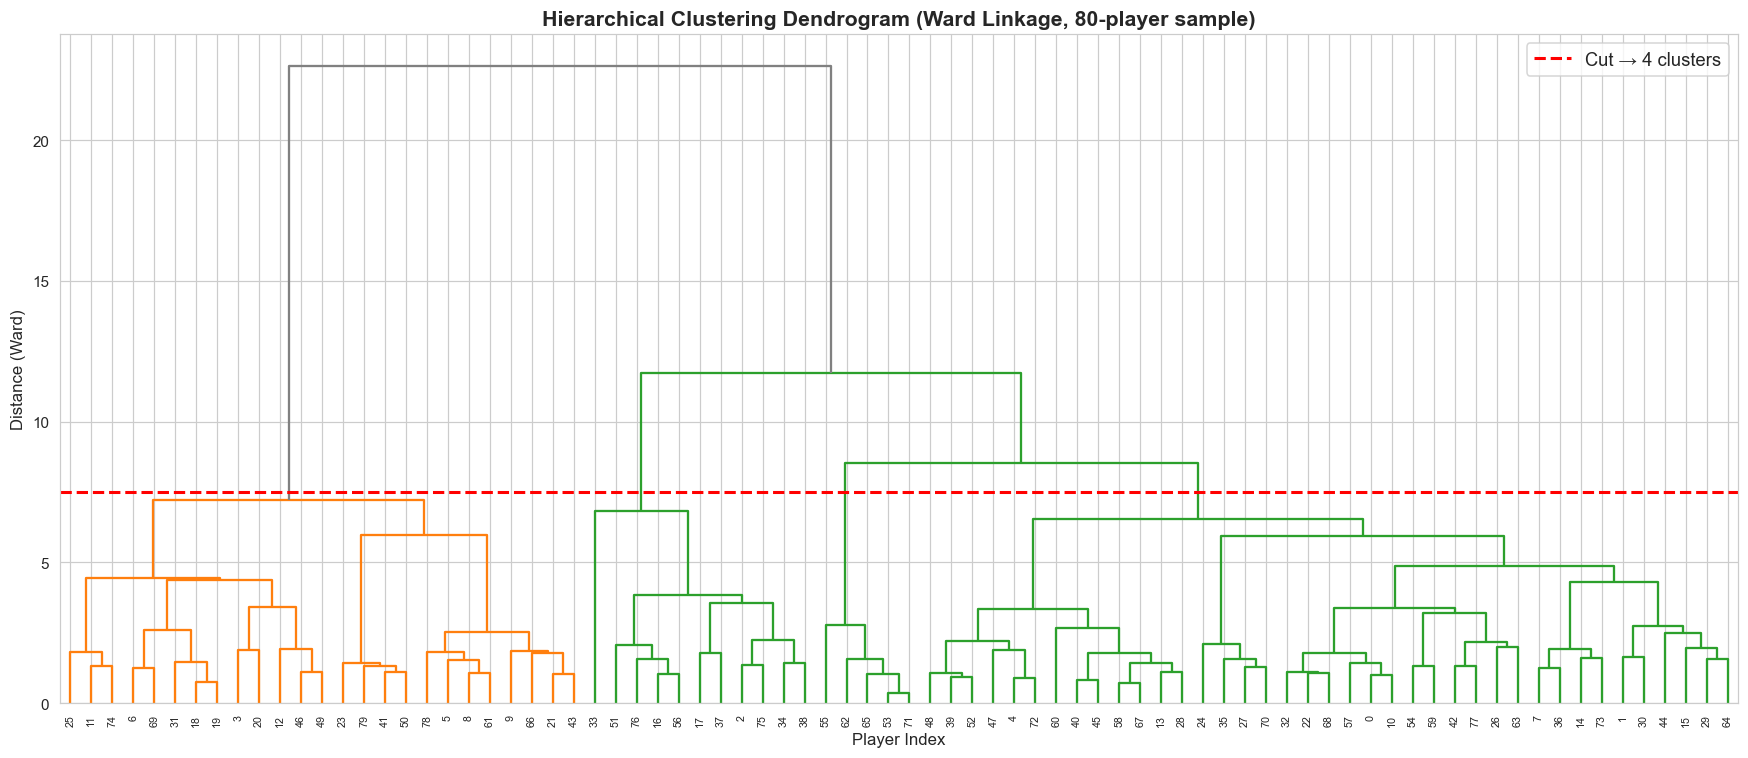

Dendrogram plotted — red dashed line shows where we cut to get 4 clusters


In [109]:
#5.1 Dendrogram 
# Use a sample for the dendrogram (full data is too dense visually)
sample_idx = np.random.choice(len(X_scaled), size=80, replace=False)
X_sample   = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(linked, ax=ax, color_threshold=0.7 * max(linked[:, 2]),
           above_threshold_color='grey', leaf_rotation=90, leaf_font_size=7)
ax.axhline(y=7.5, color='red', linestyle='--', linewidth=2,
           label='Cut → 4 clusters')
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage, 80-player sample)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Player Index', fontsize=11)
ax.set_ylabel('Distance (Ward)', fontsize=11)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', bbox_inches='tight')
plt.show()
print("Dendrogram plotted — red dashed line shows where we cut to get 4 clusters")


In [110]:
#5.2 Fit Hierarchical Model (full data)
hc = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)
df['hc_cluster'] = hc_labels

hc_sil = silhouette_score(X_scaled, hc_labels)
print(f"Hierarchical Clustering fitted")
print(f"   Silhouette Score: {hc_sil:.4f}")
print(f"\nCluster distribution:")
print(df['hc_cluster'].value_counts().sort_index())


Hierarchical Clustering fitted
   Silhouette Score: 0.2899

Cluster distribution:
hc_cluster
0    107
1     58
2     29
3     11
Name: count, dtype: int64


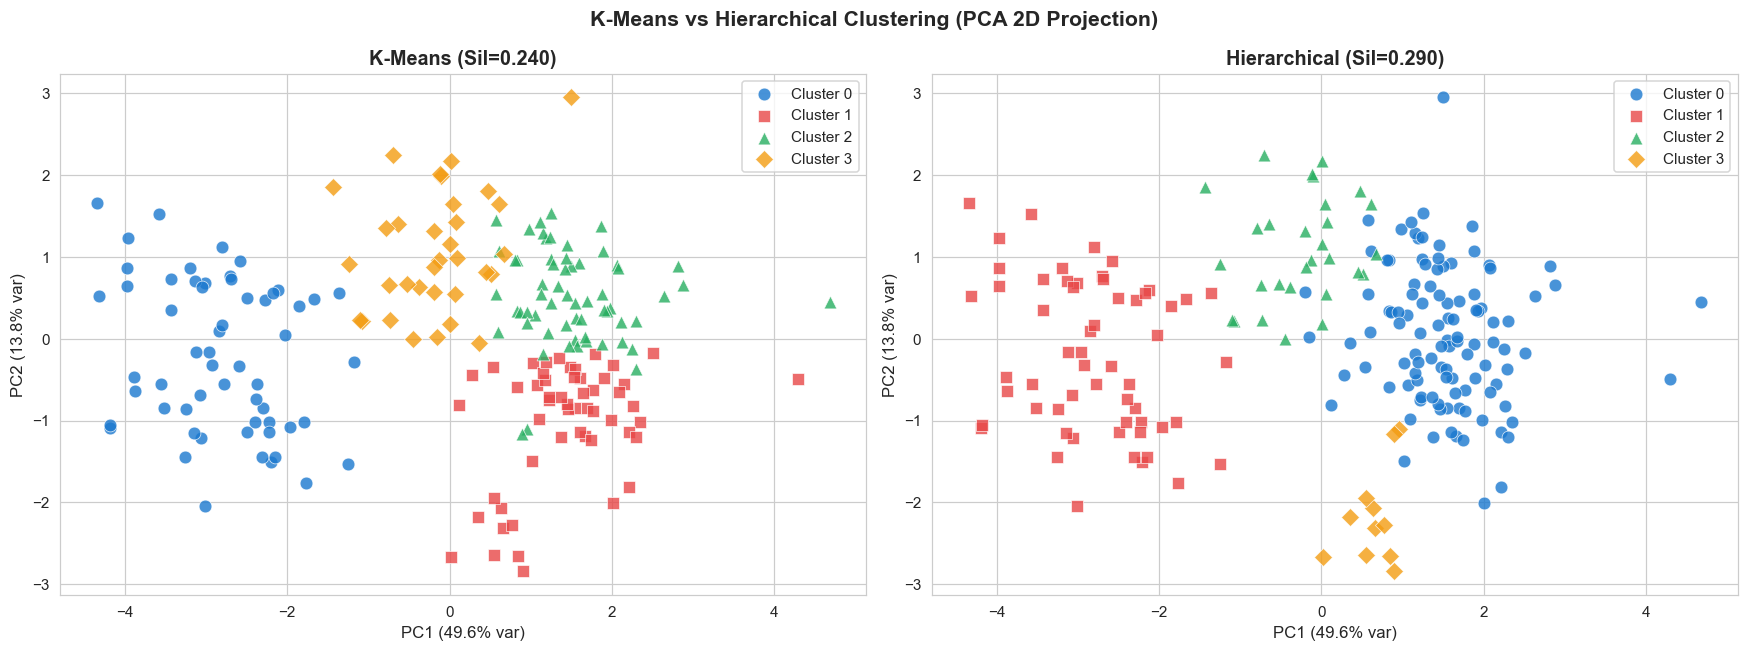

In [111]:
#5.3 Visualise HC Clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (labels, title) in zip(axes, [
    (kmeans_labels, f'K-Means (Sil={sil_avg:.3f})'),
    (hc_labels,     f'Hierarchical (Sil={hc_sil:.3f})')
]):
    for c in range(OPTIMAL_K):
        mask = labels == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=cluster_colors[c], marker=cluster_markers[c],
                   s=70, alpha=0.8, edgecolors='white', linewidth=0.5,
                   label=f'Cluster {c}')
    ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)', fontsize=11)
    ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)

plt.suptitle('K-Means vs Hierarchical Clustering (PCA 2D Projection)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_clusters.png', bbox_inches='tight')
plt.show()


## Step 6: Model Evaluation & Interpretation




In [112]:
#6.1 Evaluation Metrics
print("CLUSTERING EVALUATION SUMMARY")
print(f"{'Metric':<30} {'K-Means':>10} {'Hierarchical':>12}")
print(f"{'Silhouette Score':<30} {sil_avg:>10.4f} {hc_sil:>12.4f}")
print(f"{'Inertia (K-Means only)':<30} {kmeans.inertia_:>10,.1f} {'N/A':>12}")
print(f"{'Num Clusters':<30} {OPTIMAL_K:>10} {OPTIMAL_K:>12}")
print()
better = 'K-Means' if sil_avg >= hc_sil else 'Hierarchical'
print(f"Better model on this dataset: {better}")
print(f"(Higher Silhouette Score = better-defined, separated clusters)")


CLUSTERING EVALUATION SUMMARY
Metric                            K-Means Hierarchical
Silhouette Score                   0.2404       0.2899
Inertia (K-Means only)              722.4          N/A
Num Clusters                            4            4

Better model on this dataset: Hierarchical
(Higher Silhouette Score = better-defined, separated clusters)


In [113]:
#6.2 Cluster Profiles — Mean Stats Per Cluster
profile_cols = ['batting_avg', 'strike_rate', 'runs_scored',
                'wickets', 'economy_rate', 'bowling_avg',
                'experience_years']

cluster_profiles = df.groupby('kmeans_cluster')[profile_cols].mean().round(2)
print("K-Means Cluster Profiles (mean feature values):")
print(cluster_profiles.to_string())


K-Means Cluster Profiles (mean feature values):
                batting_avg  strike_rate  runs_scored  wickets  economy_rate  bowling_avg  experience_years
kmeans_cluster                                                                                             
0                     14.34        99.30        57.91    13.98          7.84        24.00              8.05
1                     36.10       142.72       487.30     1.53          9.82        55.69              5.09
2                     37.33       147.30       529.03     1.30          9.15        54.50             10.51
3                     29.81       130.27       336.61     9.55          8.55        30.04              7.67


In [114]:
#6.3 Interpret Clusters in IPL Context 

print("IPL CLUSTER INTERPRETATION")


for c in range(OPTIMAL_K):
    grp = df[df['kmeans_cluster'] == c]
    top_role = grp['player_role'].value_counts().idxmax()
    n = len(grp)
    avg_bat  = grp['batting_avg'].mean()
    avg_sr   = grp['strike_rate'].mean()
    avg_wkts = grp['wickets'].mean()
    avg_eco  = grp['economy_rate'].mean()
    
    if avg_bat > 30 and avg_sr > 135:
        archetype = "Explosive Batsmen"
    elif avg_bat > 25 and avg_wkts > 10:
        archetype = "All-Rounders"
    elif avg_wkts > 12 and avg_eco < 8.5:
        archetype = "Specialist Bowlers"
    else:
        archetype = "Anchor / Utility Players"
    
    print(f"\nCluster {c} — {archetype}")
    print(f"  Players:      {n}")
    print(f"  Dominant role: {top_role}")
    print(f"  Batting Avg:  {avg_bat:.1f}  |  Strike Rate: {avg_sr:.1f}")
    print(f"  Wickets:      {avg_wkts:.1f}  |  Economy:     {avg_eco:.2f}")
    print(f"  Auction tip:  ", end="")
    if "Explosive" in archetype:
        print("High-value finishers — bid aggressively!")
    elif "All-Round" in archetype:
        print("Squad balance makers — worth premium price")
    elif "Bowler" in archetype:
        print("Death-over or powerplay specialists")
    else:
        print("Budget picks for middle-order stability")




IPL CLUSTER INTERPRETATION

Cluster 0 — Specialist Bowlers
  Players:      58
  Dominant role: Bowler
  Batting Avg:  14.3  |  Strike Rate: 99.3
  Wickets:      14.0  |  Economy:     7.84
  Auction tip:  Death-over or powerplay specialists

Cluster 1 — Explosive Batsmen
  Players:      53
  Dominant role: Batsman
  Batting Avg:  36.1  |  Strike Rate: 142.7
  Wickets:      1.5  |  Economy:     9.82
  Auction tip:  High-value finishers — bid aggressively!

Cluster 2 — Explosive Batsmen
  Players:      61
  Dominant role: Batsman
  Batting Avg:  37.3  |  Strike Rate: 147.3
  Wickets:      1.3  |  Economy:     9.15
  Auction tip:  High-value finishers — bid aggressively!

Cluster 3 — Anchor / Utility Players
  Players:      33
  Dominant role: All-rounder
  Batting Avg:  29.8  |  Strike Rate: 130.3
  Wickets:      9.5  |  Economy:     8.55
  Auction tip:  Budget picks for middle-order stability


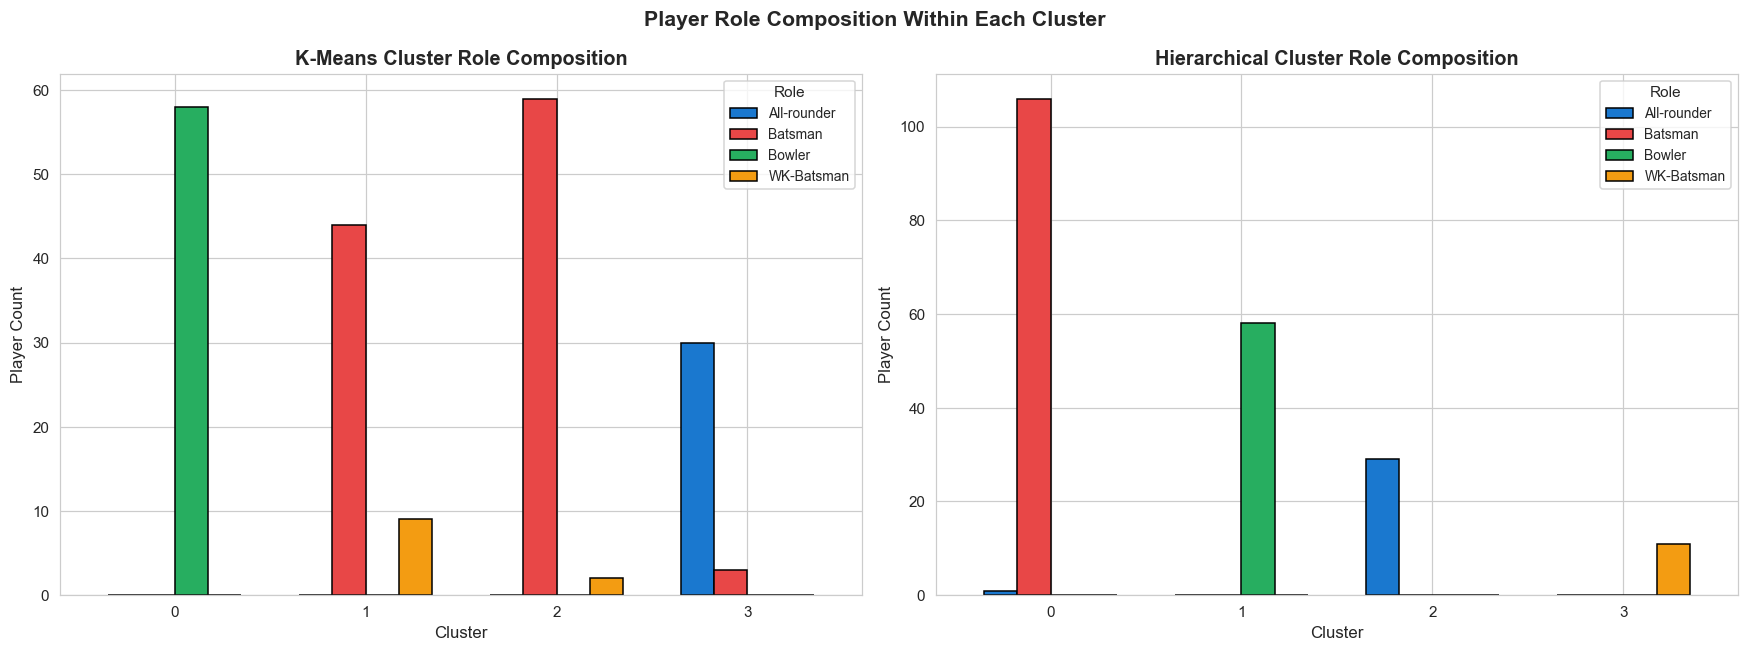

In [115]:
#6.4 Role composition per cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in zip(axes,
    ['kmeans_cluster', 'hc_cluster'],
    ['K-Means Cluster Role Composition', 'Hierarchical Cluster Role Composition']):
    
    ct = pd.crosstab(df[col], df['player_role'])
    ct.plot(kind='bar', ax=ax, color=['#1a78cf','#e84747','#27ae60','#f39c12'],
            edgecolor='black', width=0.7)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Cluster', fontsize=11)
    ax.set_ylabel('Player Count', fontsize=11)
    ax.legend(title='Role', fontsize=9)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Player Role Composition Within Each Cluster',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_role_composition.png', bbox_inches='tight')
plt.show()


## Step 7: Effect of Changing k on Clusters

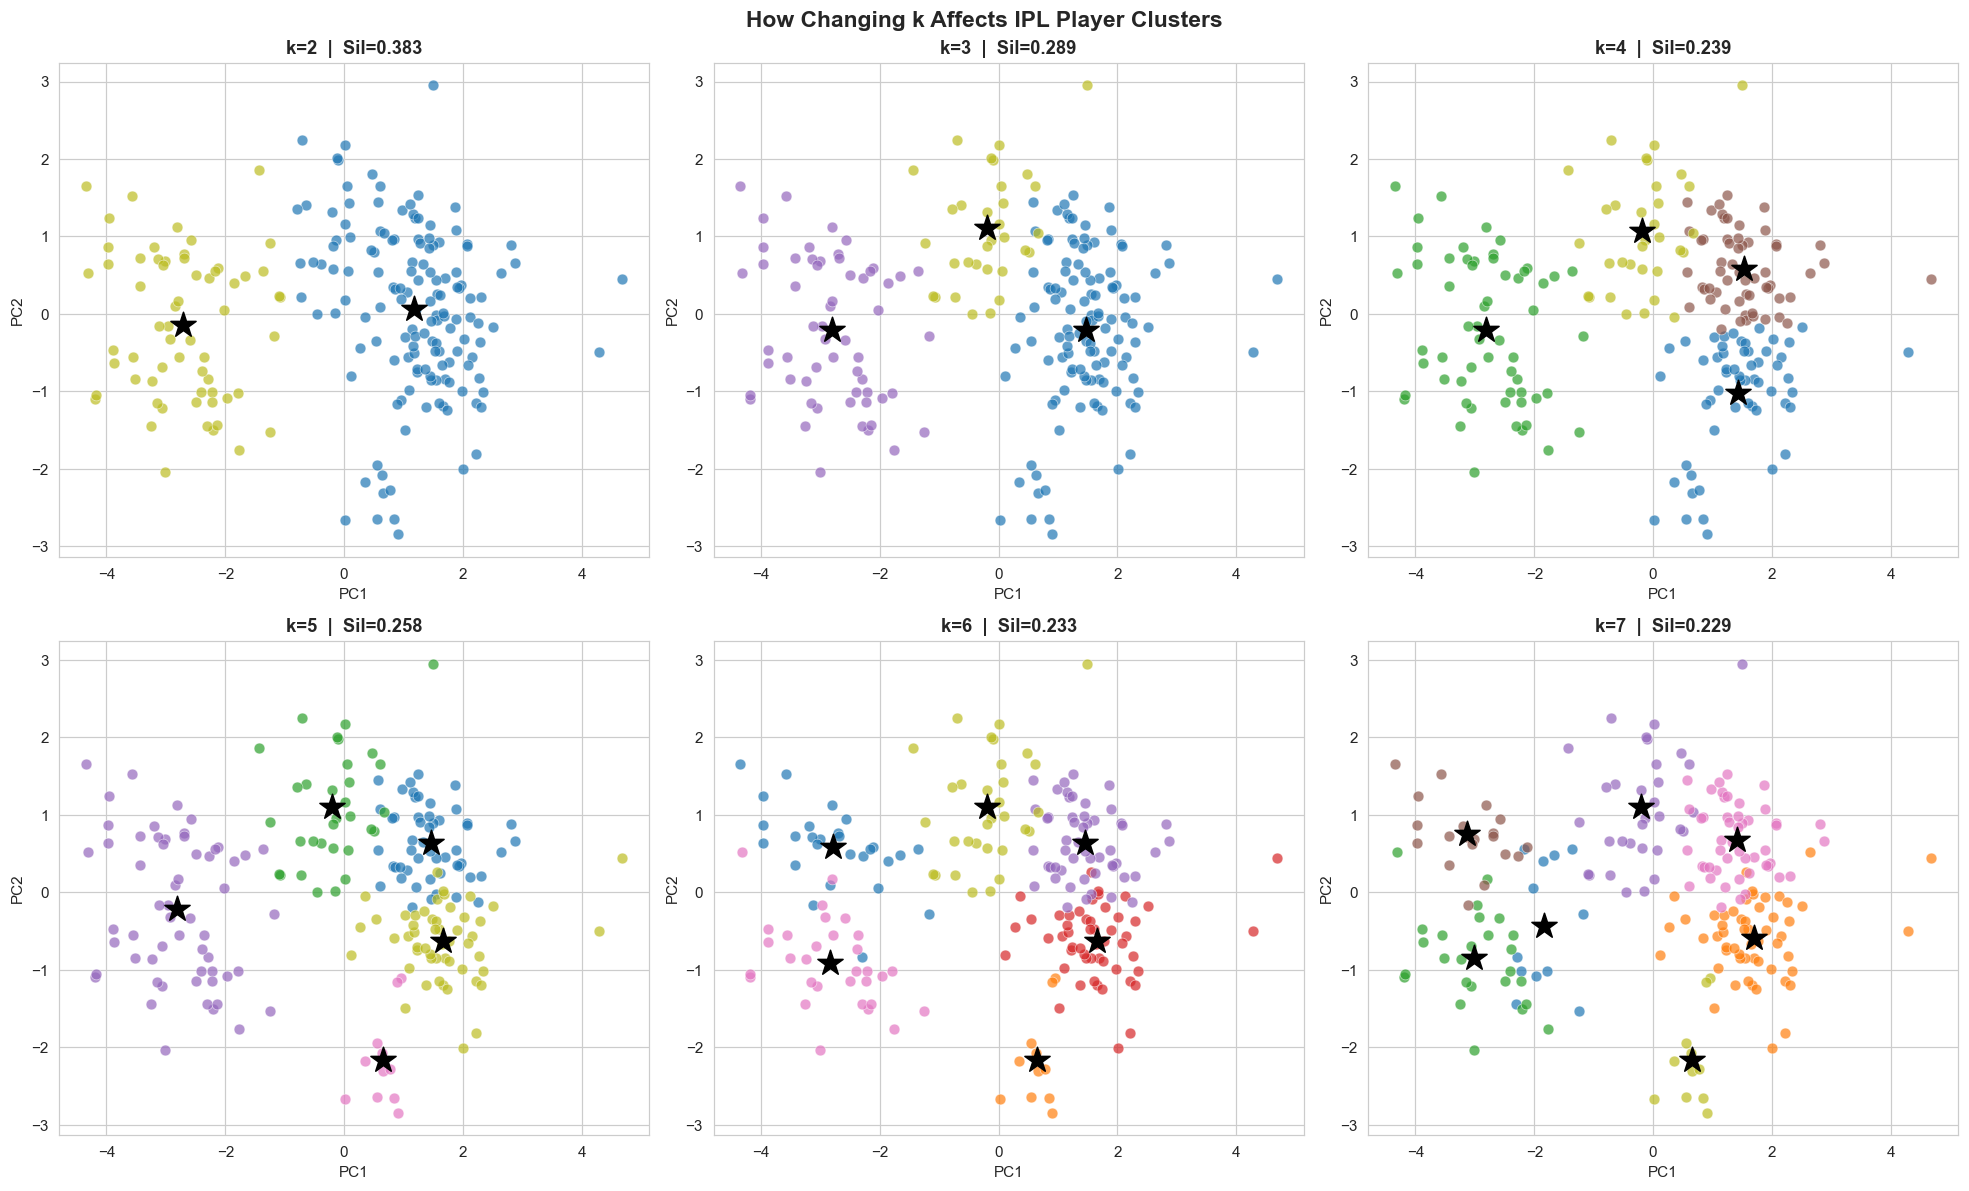

In [116]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
k_vals = [2, 3, 4, 5, 6, 7]

for ax, k in zip(axes, k_vals):
    km_temp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lab_temp = km_temp.fit_predict(X_scaled)
    sil_temp = silhouette_score(X_scaled, lab_temp)
    
    colors_cycle = plt.cm.tab10(np.linspace(0, 0.8, k))
    for c in range(k):
        mask = lab_temp == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   color=colors_cycle[c], s=50, alpha=0.7,
                   edgecolors='white', linewidth=0.4)
    
    c_pca = pca.transform(km_temp.cluster_centers_)
    ax.scatter(c_pca[:, 0], c_pca[:, 1], c='black', marker='*', s=300, zorder=5)
    ax.set_title(f'k={k}  |  Sil={sil_temp:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('How Changing k Affects IPL Player Clusters', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('effect_of_k.png', bbox_inches='tight')
plt.show()



## Step 8: Key Observations & Learnings

1. Data Creation
Real-world datasets inherently contain noise, missing values, and outliers.
Extreme cases (e.g., a 973-run season) can significantly distort cluster centroids if left untreated.
Handling such anomalies is essential to maintain realistic modeling.
2. Exploratory Data Analysis (EDA)
Correlation analysis revealed that batting metrics and bowling metrics form distinct groups, supporting the need for multiple clusters.
Approximately 15% missing data was observed.
Median imputation was preferred over mean since it is more robust to outliers and better preserves the data distribution.
3. Preprocessing
Feature scaling is crucial:
Without scaling, features like runs_scored (0–1000) would dominate smaller-scale features like wickets (0–40) in distance-based algorithms.
Winsorization was used instead of removing outliers:
Preserves dataset size
Reduces influence of extreme values
Retains meaningful real-world observations
4. K-Means Clustering
k-means++ initialization improves clustering by avoiding poor random centroid placement.
The Elbow Method helps identify K but can be subjective.
The Silhouette Score provides a more objective evaluation of clustering quality.
The chosen value K = 4 aligns well with common cricket player archetypes.
5. Hierarchical Clustering
The dendrogram offers an intuitive visualization of how clusters are formed and merged.
Ward linkage produces compact and balanced clusters compared to single or complete linkage.
Achieves clustering quality comparable to K-Means, but with higher computational cost (O(n²)).
6. Evaluation & Insights
Clustering is an unsupervised task, meaning there is no definitive ground truth.
Evaluation relies on:
Internal metrics (Silhouette Score, Inertia)
Domain knowledge for interpretation
The practical outcome:
Enables segmentation of players into meaningful groups
Supports data-driven auction strategies
Helps identify undervalued players and role-specific gaps in a team